<div dir="rtl" align="right">

<h1>מטלה בלמידת מכונה – ניתוח טקסט (סיווג נושאים)</h1>

<p><strong>סוג המטלה:</strong> ניתוח טקסט (NLP)<br>
<strong>סוג הלמידה:</strong> classification (multi-class)<br>
<strong>אלגוריתם:</strong> Multinomial Naive Bayes – מימוש עצמי<br>
<strong>Dataset:</strong> 20 Newsgroups (bydate) – עם train/test מוכנים מראש<br>
<strong>Kaggle:</strong> https://www.kaggle.com/datasets/mohamedtharwat/20news-bydate</p>

<p>ה-dataset כבר מחולק רשמית ל-train ול-test לפי תאריך.<br>
במטלה טוענים את שני הסטים ולא מחלקים אותם מחדש.</p>

</div>

<div dir="rtl" align="right">

<h2>חלק 1 – הקדמה</h2>

<h3>פרטי סטודנט</h3>
<ul>
<li>שם פרטי + אות ראשונה של שם משפחה: <strong>נעם ס</strong></li>
<li>4 ספרות אחרונות של ת.ז.: <strong>6331</strong></li>
</ul>

<h3>שימוש ב-AI / מקורות עזר</h3>

<table>
<thead>
<tr>
<th align="right">כלי / מקור</th>
<th align="right">Prompt</th>
<th align="right">מטרת השימוש</th>
</tr>
</thead>
<tbody>
<tr>
<td>ChatGPT</td>
<td>״עזור לי להבין את דרישות המטלה ואת השלבים שאני צריך לבצע.״</td>
<td>עזרה בהבנת העבודה והדרישות</td>
</tr>
<tr>
<td>ChatGPT</td>
<td>״תקן את המחברת: טעינה מתיקיות train/test, StratifiedKFold על כל ה-train, בלי subsample.״</td>
<td>דיוק מבנה העבודה והנתונים בהתאם לדרישות המטלה</td>
</tr>
<tr>
<td>ChatGPT</td>
<td>״עזור לי לממש Multinomial Naive Bayes עם fit, predict ו-alpha, ולהשתמש ב-BoW/TF-IDF.״</td>
<td>עזרה בכתיבת קוד מסוים ובהבנת המימוש</td>
</tr>
<tr>
<td>חומרי הקורס</td>
<td>מצגות ותרגולים בנושא Feature Engineering, Naive Bayes ותהליך למידה מונחית</td>
<td>הבנת החומר והמושגים המקצועיים</td>
</tr>
</tbody>
</table>

<p><strong>הערה:</strong> השימוש ב-AI היה לעזרה בהבנת העבודה, בכתיבת קטעי קוד מסוימים ובדיוק הנתונים והתאמתם לדרישות המטלה.</p>

<h3>הסבר על הבעיה וה-dataset</h3>

<p>אנחנו מסווגים פוסטים מקבוצות דיון (newsgroups) לאחת מ-20 קטגוריות נושא,
למשל <code>rec.sport.hockey</code>, <code>sci.space</code> ו-<code>talk.politics.mideast</code>.</p>

<p>הגרסה <strong>bydate</strong> ב-Kaggle מגיעה עם חלוקה רשמית מראש:</p>
<ul>
<li><code>train</code> – 11,314 דוגמאות</li>
<li><code>test</code> – 7,532 דוגמאות</li>
</ul>

<p>לכן במטלה אנחנו רק טוענים את שני הסטים, בלי <code>train_test_split</code>.</p>

<p>כל דוגמה היא טקסט. ממירים אותו ל-BoW או TF-IDF ומסווגים באמצעות Multinomial Naive Bayes שמומש ידנית.<br>
מדד האיכות הוא <strong>macro-average F1</strong>.</p>

</div>

In [1]:
from pathlib import Path
import re
import ast
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

pd.set_option("display.max_colwidth", 120)
np.random.seed(42)

# ------------------------------------------------------------
# Dataset setup
# The Kaggle archive already contains:
#   20news-bydate-train/
#   20news-bydate-test/
# We do NOT perform train_test_split.
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_ZIPS = [
    NOTEBOOK_DIR / "archive.zip",
    NOTEBOOK_DIR / "assignment" / "archive.zip",
    Path("../assignment/archive.zip"),
    Path("assignment/archive.zip"),
]
CANDIDATE_EXTRACT_DIRS = [
    NOTEBOOK_DIR / "20news_data",
    NOTEBOOK_DIR / "assignment" / "20news_data",
    Path("../data/20newsgroups"),
    Path("data/20newsgroups"),
]

ZIP_PATH = next((p for p in CANDIDATE_ZIPS if p.exists()), None)
EXTRACT_DIR = None

# Prefer already-extracted official folders if present
for d in CANDIDATE_EXTRACT_DIRS:
    if (d / "20news-bydate-train").exists() and (d / "20news-bydate-test").exists():
        EXTRACT_DIR = d
        break

if EXTRACT_DIR is None:
    EXTRACT_DIR = NOTEBOOK_DIR / "20news_data"
    if ZIP_PATH is None:
        try:
            from google.colab import files
            print("Please upload the Kaggle archive.zip file.")
            uploaded = files.upload()
            ZIP_PATH = Path(next(iter(uploaded)))
        except Exception as e:
            raise FileNotFoundError(
                "archive.zip was not found. Put it next to the notebook "
                "or upload it when running in Colab."
            ) from e

    if not (EXTRACT_DIR / "20news-bydate-train").exists():
        EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(EXTRACT_DIR)
        # handle archive that extracts into a nested folder
        nested_train = list(EXTRACT_DIR.rglob("20news-bydate-train"))
        if nested_train and nested_train[0].parent != EXTRACT_DIR:
            EXTRACT_DIR = nested_train[0].parent

TRAIN_DIR = EXTRACT_DIR / "20news-bydate-train"
TEST_DIR = EXTRACT_DIR / "20news-bydate-test"

assert TRAIN_DIR.exists(), f"Missing: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing: {TEST_DIR}"

print("Dataset ready.")
print("Train directory:", TRAIN_DIR)
print("Test directory :", TEST_DIR)


Matplotlib is building the font cache; this may take a moment.


Dataset ready.
Train directory: ../data/20newsgroups/20news-bydate-train
Test directory : ../data/20newsgroups/20news-bydate-test


In [2]:
def load_split(root_folder: Path) -> pd.DataFrame:
    """Load one predefined split directly from the Kaggle folder structure."""
    rows = []

    for category_folder in sorted(root_folder.iterdir()):
        if not category_folder.is_dir():
            continue

        category = category_folder.name

        for file_path in sorted(category_folder.iterdir()):
            if not file_path.is_file():
                continue

            # 20 Newsgroups is an old English text corpus.
            # latin-1 safely decodes the original files.
            text = file_path.read_text(encoding="latin-1", errors="replace")

            rows.append({
                "file_id": file_path.name,
                "category": category,
                "text": text
            })

    return pd.DataFrame(rows)


train_df = load_split(TRAIN_DIR)
test_df = load_split(TEST_DIR)

train_df["label"] = train_df["category"].astype(str).str.strip()
test_df["label"] = test_df["category"].astype(str).str.strip()

LABEL_NAMES = sorted(train_df["label"].unique().tolist())

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Num classes:", len(LABEL_NAMES))

assert len(train_df) == 11314, f"Unexpected train size: {len(train_df)}"
assert len(test_df) == 7532, f"Unexpected test size: {len(test_df)}"
assert len(LABEL_NAMES) == 20, f"Unexpected number of classes: {len(LABEL_NAMES)}"
assert set(train_df["label"]) == set(test_df["label"]), "Train/test classes differ"

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index())


Train shape: (11314, 4)
Test shape : (7532, 4)
Num classes: 20

Train label counts:
label
alt.atheism                 480
comp.graphics               584
comp.os.ms-windows.misc     591
comp.sys.ibm.pc.hardware    590
comp.sys.mac.hardware       578
comp.windows.x              593
misc.forsale                585
rec.autos                   594
rec.motorcycles             598
rec.sport.baseball          597
rec.sport.hockey            600
sci.crypt                   595
sci.electronics             591
sci.med                     594
sci.space                   593
soc.religion.christian      599
talk.politics.guns          546
talk.politics.mideast       564
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64

Test label counts:
label
alt.atheism                 319
comp.graphics               389
comp.os.ms-windows.misc     394
comp.sys.ibm.pc.hardware    392
comp.sys.mac.hardware       385
comp.windows.x              395
misc.forsale              

<div dir="rtl" align="right">
<h3>5 השורות הראשונות – Train</h3>
</div>

In [3]:
train_df.head(5)

,file_id,category,text,label
0,49960,alt.atheism,"From: mathew <mathew@mantis.co.uk>\nSubject: Alt.Atheism FAQ: Atheist Resources\nSummary: Books, addresses, music --...",alt.atheism
1,51060,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: Alt.Atheism FAQ: Introduction to Atheism\nSummary: Please read this fil...,alt.atheism
2,51119,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Rosenau)\nSubject: Re: Gospel Dating\nOrganization: Technical University...,alt.atheism
3,51120,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: Re: university violating separation of church/state?\nOrganization: Man...,alt.atheism
4,51121,alt.atheism,"From: strom@Watson.Ibm.Com (Rob Strom)\nSubject: Re: [soc.motss, et al.] ""Princeton axes matching funds for Boy Scou...",alt.atheism


<div dir="rtl" align="right">
<h3>5 השורות הראשונות – Test</h3>
</div>

In [4]:
test_df.head(5)

,file_id,category,text,label
0,53068,alt.atheism,From: decay@cbnewsj.cb.att.com (dean.kaflowitz)\nSubject: Re: about the bible quiz answers\nOrganization: AT&T\nDist...,alt.atheism
1,53257,alt.atheism,From: cfaehl@vesta.unm.edu (Chris Faehl)\nSubject: Re: Amusing atheists and agnostics\nOrganization: University of N...,alt.atheism
2,53260,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: Re: Yet more Rushdie [Re: ISLAMIC LAW]\nOrganization: Mantis Consultant...,alt.atheism
3,53261,alt.atheism,"From: dps@nasa.kodak.com (Dan Schaertel,,,)\nSubject: Re: Christian Morality is\nReply-To: dps@nasa.kodak.com\nOrgan...",alt.atheism
4,53262,alt.atheism,"From: halat@panther.bears (Jim Halat)\nSubject: Re: After 2000 years, can we say that Christian Morality is\nReply-T...",alt.atheism


<div dir="rtl" align="right">

<h2>מדד האיכות</h2>

<p>זו בעיית <strong>סיווג multi-class עם 20 מחלקות</strong>, ללא מחלקה מרכזית אחת.</p>

<p>לפי הנחיות המטלה, מדד האיכות הוא <strong>macro-average F1</strong>:
מחשבים F1 לכל מחלקה בנפרד ואז לוקחים ממוצע שווה בין כל 20 המחלקות.</p>

</div>

In [5]:
def quality_metric(y_true, y_pred) -> float:
    """Macro-average F1 – מדד האיכות למטלה."""
    return f1_score(y_true, y_pred, average="macro")

print("Quality metric: macro-average F1")

Quality metric: macro-average F1


<div dir="rtl" align="right">

<h2>חלק 2 – Feature Engineering</h2>

<p>הטקסט הגולמי אינו קלט מספרי, ולכן צריך להפוך אותו ל-feature vectors.</p>

<p><strong>השלבים:</strong></p>
<ol>
<li><strong>Text preprocessing</strong> – המרה ל-lowercase, הסרת מספרים וסימנים ואיחוד רווחים.</li>
<li><strong>Token representation</strong> – ייצוג המילים כמאפיינים.</li>
<li><strong>Bag-of-Words / TF-IDF</strong> – הפיכת כל מסמך לווקטור מספרי.</li>
<li>במסגרת הבונוס נבדקים גם <strong>unigrams</strong> לעומת <strong>unigrams + bigrams</strong>.</li>
</ol>

<p>את ה-vectorizer מתאימים באמצעות <code>fit</code> רק על ה-train,
ועל ה-test מפעילים <code>transform</code> בלבד, כדי למנוע זליגת מידע מה-test לתהליך הלמידה.</p>

<p>התהליך מוצג על 2–3 דוגמאות מה-train ומה-test, כנדרש במטלה.</p>

</div>

In [6]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].map(clean_text)
test_df["text_clean"] = test_df["text"].map(clean_text)

demo_train = train_df.head(3).copy()
demo_test = test_df.head(3).copy()

print("=== TRAIN examples: raw -> clean ===")
for _, row in demo_train.iterrows():
    print(f"\n[{row['label']}]")
    print("RAW :", row["text"][:180], "...")
    print("CLEAN:", row["text_clean"][:180], "...")

print("\n=== TEST examples: raw -> clean ===")
for _, row in demo_test.iterrows():
    print(f"\n[{row['label']}]")
    print("RAW :", row["text"][:180], "...")
    print("CLEAN:", row["text_clean"][:180], "...")


=== TRAIN examples: raw -> clean ===

[alt.atheism]
RAW : From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Atheist Resources
Summary: Books, addresses, music -- anything related to atheism
Keywords: FAQ, atheism, books, music, ...
CLEAN: from mathew mathew mantis co uk subject alt atheism faq atheist resources summary books addresses music anything related to atheism keywords faq atheism books music fiction address ...

[alt.atheism]
RAW : From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Introduction to Atheism
Summary: Please read this file before posting to alt.atheism
Keywords: FAQ, atheism
Expires: Th ...
CLEAN: from mathew mathew mantis co uk subject alt atheism faq introduction to atheism summary please read this file before posting to alt atheism keywords faq atheism expires thu may gmt ...

[alt.atheism]
RAW : From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Rosenau)
Subject: Re: Gospel Dating
Organization: Technical University Braunschweig, Germany
Lines: 93

In [7]:
def build_vectorizer(
    method: str = "tfidf",
    max_features: int = 10000,
    ngram_range=(1, 1),
    min_df: int = 2,
):
    """בונה vectorizer לפי שיטת FE שנלמדה לקורס."""
    common = dict(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words="english",
    )
    if method == "bow":
        return CountVectorizer(**common)
    if method == "tfidf":
        return TfidfVectorizer(**common)
    raise ValueError("method must be 'bow' or 'tfidf'")


def fit_transform_features(train_texts, test_texts, **fe_params):
    vectorizer = build_vectorizer(**fe_params)
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    return vectorizer, X_train, X_test


DEFAULT_FE = dict(method="tfidf", max_features=10000, ngram_range=(1, 2), min_df=2)
vectorizer_demo, X_train_demo, X_test_demo = fit_transform_features(
    train_df["text_clean"], test_df["text_clean"], **DEFAULT_FE
)

print("FE params:", DEFAULT_FE)
print("X_train:", X_train_demo.shape, "| X_test:", X_test_demo.shape)

feature_names = np.array(vectorizer_demo.get_feature_names_out())

def show_top_features(row_vec, title, k=12):
    row = row_vec.toarray().ravel()
    idx = row.nonzero()[0]
    if len(idx) == 0:
        print(title, "-> empty vector")
        return
    top = idx[np.argsort(row[idx])[::-1][:k]]
    pairs = [f"{feature_names[j]}={row[j]:.3f}" for j in top]
    print(title)
    print("  ", ", ".join(pairs))

print("\nTop features – TRAIN examples:")
for i in range(3):
    show_top_features(X_train_demo[i], f"train[{i}] ({train_df.iloc[i]['label']})")

print("\nTop features – TEST examples:")
for i in range(3):
    show_top_features(X_test_demo[i], f"test[{i}] ({test_df.iloc[i]['label']})")


FE params: {'method': 'tfidf', 'max_features': 10000, 'ngram_range': (1, 2), 'min_df': 2}
X_train: (11314, 10000) | X_test: (7532, 10000)

Top features – TRAIN examples:
train[0] (alt.atheism)
   atheism=0.294, books=0.245, atheist=0.223, god=0.219, existence god=0.165, fish=0.154, press=0.147, bible=0.147, isbn=0.138, mantis=0.130, existence=0.122, african=0.110
train[1] (alt.atheism)
   atheists=0.512, atheism=0.399, religious=0.280, god=0.273, religion=0.174, belief=0.150, atheist=0.129, beliefs=0.111, religions=0.110, believe=0.110, exist=0.107, theists=0.106
train[2] (alt.atheism)
   luke=0.541, john=0.332, mark=0.245, matthew=0.206, gospel=0.139, evidence=0.132, generally=0.111, obvious=0.109, knowledge=0.106, argument=0.104, text=0.104, texts=0.101

Top features – TEST examples:
test[0] (alt.atheism)
   covenant=0.285, healta saturn=0.282, healta=0.282, wwc edu=0.259, saturn wwc=0.259, wwc=0.257, dean=0.228, saturn=0.225, image=0.183, word=0.158, original=0.158, tammy=0.136
test

<div dir="rtl" align="right">

<h2>חלק 3 – מימוש אלגוריתם: Multinomial Naive Bayes</h2>

<h3>רעיון קצר</h3>
<p>Naive Bayes מניח אי-תלות מותנית בין המאפיינים. לסיווג טקסט משתמשים בגרסה <strong>Multinomial</strong>.</p>

</div>

$$
\hat{y} = \arg\max_c \left[ \log P(c) + \sum_j x_j \log P(w_j \mid c) \right]
$$

<div dir="rtl" align="right">

<p>משתמשים ב-<strong>Laplace / Lidstone smoothing</strong> באמצעות ההיפר-פרמטר <code>alpha</code>.</p>

</div>

$$
P(w_j \mid c) = \frac{N_{c,j} + \alpha}{N_c + \alpha V}
$$

<div dir="rtl" align="right">

<h3>Hyperparameters</h3>
<ul>
<li><code>alpha</code> – פרמטר smoothing. ערכים שנבדקו בעבודה: 0.5 ו-1.0.</li>
</ul>

<p>המחלקה כוללת <code>fit</code> לאימון ו-<code>predict</code> לחיזוי.</p>

</div>

In [8]:
class MultinomialNaiveBayes:
    """Multinomial Naive Bayes – מימוש עצמי (לא sklearn)."""

    def __init__(self, alpha: float = 1.0):
        self.alpha = float(alpha)
        self.classes_ = None
        self.class_log_prior_ = None
        self.feature_log_prob_ = None

    def fit(self, X, y):
        X = X.tocsr() if hasattr(X, "tocsr") else np.asarray(X)
        y = np.asarray(y)
        self.classes_, y_idx = np.unique(y, return_inverse=True)
        n_classes = len(self.classes_)
        n_features = X.shape[1]
        n_samples = X.shape[0]

        class_count = np.bincount(y_idx, minlength=n_classes).astype(float)
        self.class_log_prior_ = np.log(class_count) - np.log(n_samples)

        feature_count = np.zeros((n_classes, n_features), dtype=float)
        for c in range(n_classes):
            X_c = X[y_idx == c]
            feature_count[c] = np.asarray(X_c.sum(axis=0)).ravel()

        smoothed = feature_count + self.alpha
        smoothed_denom = smoothed.sum(axis=1, keepdims=True)
        self.feature_log_prob_ = np.log(smoothed) - np.log(smoothed_denom)
        return self

    def predict_log_proba(self, X):
        X = X.tocsr() if hasattr(X, "tocsr") else np.asarray(X)
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):
        log_probs = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_probs, axis=1)]


# בדיקת sanity על ה-train המלא (11,314 דוגמאות) וה-test המוגדר מראש
vec_q, Xtr_q, Xte_q = fit_transform_features(
    train_df["text_clean"], test_df["text_clean"], **DEFAULT_FE
)
nb_q = MultinomialNaiveBayes(alpha=1.0)
nb_q.fit(Xtr_q, train_df["label"].values)
pred_q = nb_q.predict(Xte_q)
print("Quick sanity macro-F1 on test:", round(quality_metric(test_df["label"], pred_q), 4))
print("classes_", nb_q.classes_)
print("alpha hyperparameter =", nb_q.alpha)


Quick sanity macro-F1 on test: 0.7647
classes_ ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']
alpha hyperparameter = 1.0


<div dir="rtl" align="right">

<h2>חלק 6 (בונוס) – Grid Search + 5-Fold Cross Validation</h2>

<p>נבדקות כל הפרמוטציות שנבחרו עבור Feature Engineering וה-hyperparameter של המודל:</p>

<ul>
<li><strong>שיטת Feature Engineering:</strong> BoW / TF-IDF</li>
<li><strong>מספר מאפיינים:</strong> 5000 / 10000</li>
<li><strong>n-gram:</strong> unigram / unigram + bigram</li>
<li><strong>alpha:</strong> 0.5 / 1.0</li>
</ul>

<p>הניסויים מבוצעים באמצעות <strong>5-fold cross-validation על כל ה-trainset</strong>.
בכל איטרציה 4 folds משמשים לאימון ו-fold אחד ל-validation.</p>

<p>ה-test set אינו משמש לבחירת הפרמטרים.
לאחר בחירת הפרמוטציה הטובה ביותר מאמנים מחדש על כל ה-train ומעריכים את המודל על ה-test.</p>

</div>

In [9]:
# All selected combinations.
# 2 methods × 2 vocabulary sizes × 2 n-gram choices × 2 alpha values = 16 permutations.

fe_grid = []
for method in ["bow", "tfidf"]:
    for max_features in [5000, 10000]:
        for ngram in [(1, 1), (1, 2)]:
            fe_grid.append(
                dict(
                    method=method,
                    max_features=max_features,
                    ngram_range=ngram,
                    min_df=2,
                )
            )

alpha_values = [0.5, 1.0]

print("Feature-engineering combinations:", len(fe_grid))
print("Alpha values:", alpha_values)
print("Total model permutations:", len(fe_grid) * len(alpha_values))


Feature-engineering combinations: 8
Alpha values: [0.5, 1.0]
Total model permutations: 16


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

texts = train_df["text_clean"].to_numpy()
labels = train_df["label"].to_numpy()

rows = []

for fe_i, fe_params in enumerate(fe_grid, start=1):
    # Keep one score list for each alpha for this FE combination.
    alpha_scores = {alpha: [] for alpha in alpha_values}

    print(f"\n=== FE combination {fe_i}/{len(fe_grid)}: {fe_params} ===")

    for fold, (tr_idx, va_idx) in enumerate(skf.split(texts, labels), start=1):
        # IMPORTANT: vectorizer is fitted only on the training folds.
        vectorizer = build_vectorizer(**fe_params)
        X_tr = vectorizer.fit_transform(texts[tr_idx])
        X_va = vectorizer.transform(texts[va_idx])

        for alpha in alpha_values:
            model = MultinomialNaiveBayes(alpha=alpha)
            model.fit(X_tr, labels[tr_idx])
            preds = model.predict(X_va)
            score = quality_metric(labels[va_idx], preds)
            alpha_scores[alpha].append(score)

        print(f"fold {fold}/5 complete")

    for alpha in alpha_values:
        fold_scores = alpha_scores[alpha]
        mean_score = float(np.mean(fold_scores))

        rows.append({
            **fe_params,
            "ngram_range": str(fe_params["ngram_range"]),
            "alpha": alpha,
            "cv_macro_f1_mean": mean_score,
            "cv_folds": fold_scores,
        })

        print(
            f"alpha={alpha} -> "
            f"mean macro-F1={mean_score:.4f} "
            f"| folds={[round(x, 4) for x in fold_scores]}"
        )

results_df = (
    pd.DataFrame(rows)
    .sort_values("cv_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

results_df



=== FE combination 1/8: {'method': 'bow', 'max_features': 5000, 'ngram_range': (1, 1), 'min_df': 2} ===


fold 1/5 complete


fold 2/5 complete


fold 3/5 complete


fold 4/5 complete


...

fold 2/5 complete


fold 3/5 complete


fold 4/5 complete


fold 5/5 complete
alpha=0.5 -> mean macro-F1=0.8473 | folds=[0.8442, 0.855, 0.8485, 0.8399, 0.8491]
alpha=1.0 -> mean macro-F1=0.8366 | folds=[0.8347, 0.846, 0.8351, 0.8253, 0.8419]


,method,max_features,ngram_range,min_df,alpha,cv_macro_f1_mean,cv_folds
0,tfidf,10000,"(1, 1)",2,0.5,0.871039,"[0.8715544453446544, 0.8708084995434249, 0.8731020192529728, 0.8608104023971211, 0.8789205170311158]"
1,tfidf,10000,"(1, 1)",2,1.0,0.859910,"[0.8578551152636388, 0.8656159663509451, 0.8647894181686819, 0.8453768811391414, 0.8659125483240988]"
2,tfidf,5000,"(1, 1)",2,0.5,0.852593,"[0.8492543862207416, 0.8569249248481002, 0.8511186620673932, 0.8424139441881101, 0.863252529255354]"
3,tfidf,10000,"(1, 2)",2,0.5,0.847340,"[0.8442017165143385, 0.8549979299241682, 0.8485430112668746, 0.8398510464495518, 0.8491045569889186]"
4,tfidf,5000,"(1, 1)",2,1.0,0.840477,"[0.8356575946349979, 0.8482827849664343, 0.8380354083200776, 0.8317303133045773, 0.8486776056498109]"
5,tfidf,10000,"(1, 2)",2,1.0,0.836604,"[0.8346801422266182, 0.846007757218643, 0.8351147775539826, 0.8252915868205172, 0.8419270855911807]"
6,bow,10000,"(1, 1)",2,0.5,0.831081,"[0.8297072891012263, 0.8420306134581154, 0.8247415118608851, 0.8213595387813187, 0.8375635822436165]"
7,bow,10000,"(1, 1)",2,1.0,0.828393,"[0.8280522553441143, 0.8379010156305429, 0.826451876295476, 0.8160916644649117, 0.8334687572697772]"
8,tfidf,5000,"(1, 2)",2,0.5,0.828131,"[0.8269632149973738, 0.8368493644792416, 0.8268863993019216, 0.8153686284269671, 0.8345873633608709]"
9,tfidf,5000,"(1, 2)",2,1.0,0.815420,"[0.815918062620024, 0.8284662281028371, 0.8107771406720434, 0.7993564873382587, 0.8225833178927502]"


In [11]:
best = results_df.iloc[0].to_dict()

BEST_FE = dict(
    method=best["method"],
    max_features=int(best["max_features"]),
    ngram_range=ast.literal_eval(best["ngram_range"]),
    min_df=int(best["min_df"]),
)
BEST_ALPHA = float(best["alpha"])

print("Best permutation:")
print(BEST_FE)
print("alpha =", BEST_ALPHA)
print("best CV macro-F1 =", round(best["cv_macro_f1_mean"], 4))


Best permutation:
{'method': 'tfidf', 'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 2}
alpha = 0.5
best CV macro-F1 = 0.871


<div dir="rtl" align="right">

<h2>חלק 4 – אימון על כל ה-Train עם הפרמוטציה המנצחת</h2>

<p>לאחר בחירת הפרמטרים הטובים ביותר, מאמנים מחדש את המודל על כל ה-Train.
מוצגות גם 2–3 דוגמאות שעוברות את תהליך ה-Feature Engineering.</p>

</div>

In [12]:
print("Training on FULL train set with best params...")
print("FE:", BEST_FE, "| alpha:", BEST_ALPHA)

final_vectorizer, X_train_full, X_test_full = fit_transform_features(
    train_df["text_clean"], test_df["text_clean"], **BEST_FE
)

feat_names = np.array(final_vectorizer.get_feature_names_out())

def show_pipeline_example(df, X, indices, split_name):
    for i in indices:
        row = df.iloc[i]
        print(f"\n--- {split_name} example {i} | true={row['label']} ---")
        print("text:", row["text"][:160], "...")
        print("clean:", row["text_clean"][:160], "...")
        vec = X[i].toarray().ravel()
        nz = vec.nonzero()[0]
        top = nz[np.argsort(vec[nz])[::-1][:10]]
        print("top features:", ", ".join(f"{feat_names[j]}={vec[j]:.3f}" for j in top))

show_pipeline_example(train_df, X_train_full, [0, 1, 2], "TRAIN")

final_model = MultinomialNaiveBayes(alpha=BEST_ALPHA)
final_model.fit(X_train_full, train_df["label"].values)
print("\nModel trained. classes_", final_model.classes_)


Training on FULL train set with best params...
FE: {'method': 'tfidf', 'max_features': 10000, 'ngram_range': (1, 1), 'min_df': 2} | alpha: 0.5



--- TRAIN example 0 | true=alt.atheism ---
text: From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Atheist Resources
Summary: Books, addresses, music -- anything related to atheism
Keywords: FAQ, at ...
clean: from mathew mathew mantis co uk subject alt atheism faq atheist resources summary books addresses music anything related to atheism keywords faq atheism books m ...
top features: atheism=0.294, books=0.246, atheist=0.224, god=0.219, fish=0.154, press=0.147, bible=0.147, isbn=0.138, mantis=0.131, existence=0.122

--- TRAIN example 1 | true=alt.atheism ---
text: From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Introduction to Atheism
Summary: Please read this file before posting to alt.atheism
Keywords: FAQ, ...
clean: from mathew mathew mantis co uk subject alt atheism faq introduction to atheism summary please read this file before posting to alt atheism keywords faq atheism ...
top features: atheists=0.517, atheism=0.403, religious=0.283, god=0.276, relig

<div dir="rtl" align="right">
<h2>חלק 5 – חיזוי ושערוך על ה-Test Set</h2>
</div>

In [13]:
show_pipeline_example(test_df, X_test_full, [0, 1, 2], "TEST")

y_test = test_df["label"].values
y_pred = final_model.predict(X_test_full)

preview = test_df.head(5)[["text", "label"]].copy()
preview["text"] = preview["text"].str.slice(0, 80)
preview["pred"] = y_pred[:5]
preview



--- TEST example 0 | true=alt.atheism ---
text: From: decay@cbnewsj.cb.att.com (dean.kaflowitz)
Subject: Re: about the bible quiz answers
Organization: AT&T
Distribution: na
Lines: 18

In article <healta.153. ...
clean: from decay cbnewsj cb att com dean kaflowitz subject re about the bible quiz answers organization at t distribution na lines in article healta saturn wwc edu he ...
top features: covenant=0.329, healta=0.324, wwc=0.296, dean=0.263, saturn=0.259, image=0.211, word=0.182, original=0.182, tammy=0.157, cbnewsj=0.156

--- TEST example 1 | true=alt.atheism ---
text: From: cfaehl@vesta.unm.edu (Chris Faehl)
Subject: Re: Amusing atheists and agnostics
Organization: University of New Mexico, Albuquerque
Lines: 88
Distribution: ...
clean: from cfaehl vesta unm edu chris faehl subject re amusing atheists and agnostics organization university of new mexico albuquerque lines distribution world nntp  ...
top features: atheism=0.423, hard=0.271, arrogant=0.269, stalin=0.239, theists=

,text,label,pred
0,From: decay@cbnewsj.cb.att.com (dean.kaflowitz)\nSubject: Re: about the bible qui,alt.atheism,alt.atheism
1,From: cfaehl@vesta.unm.edu (Chris Faehl)\nSubject: Re: Amusing atheists and agnos,alt.atheism,alt.atheism
2,From: mathew <mathew@mantis.co.uk>\nSubject: Re: Yet more Rushdie [Re: ISLAMIC LA,alt.atheism,alt.atheism
3,"From: dps@nasa.kodak.com (Dan Schaertel,,,)\nSubject: Re: Christian Morality is\nR",alt.atheism,alt.atheism
4,"From: halat@panther.bears (Jim Halat)\nSubject: Re: After 2000 years, can we say",alt.atheism,alt.atheism


Test macro-average F1: 0.8016

Classification report:
                          precision    recall  f1-score   support

             alt.atheism       0.79      0.71      0.75       319
           comp.graphics       0.66      0.73      0.70       389
 comp.os.ms-windows.misc       0.72      0.70      0.71       394
comp.sys.ibm.pc.hardware       0.64      0.74      0.68       392
   comp.sys.mac.hardware       0.82      0.81      0.82       385
          comp.windows.x       0.84      0.79      0.81       395
            misc.forsale       0.79      0.81      0.80       390
               rec.autos       0.86      0.88      0.87       396
         rec.motorcycles       0.89      0.93      0.91       398
      rec.sport.baseball       0.91      0.93      0.92       397
        rec.sport.hockey       0.92      0.97      0.95       399
               sci.crypt       0.92      0.92      0.92       396
         sci.electronics       0.78      0.65      0.71       393
                 sci.

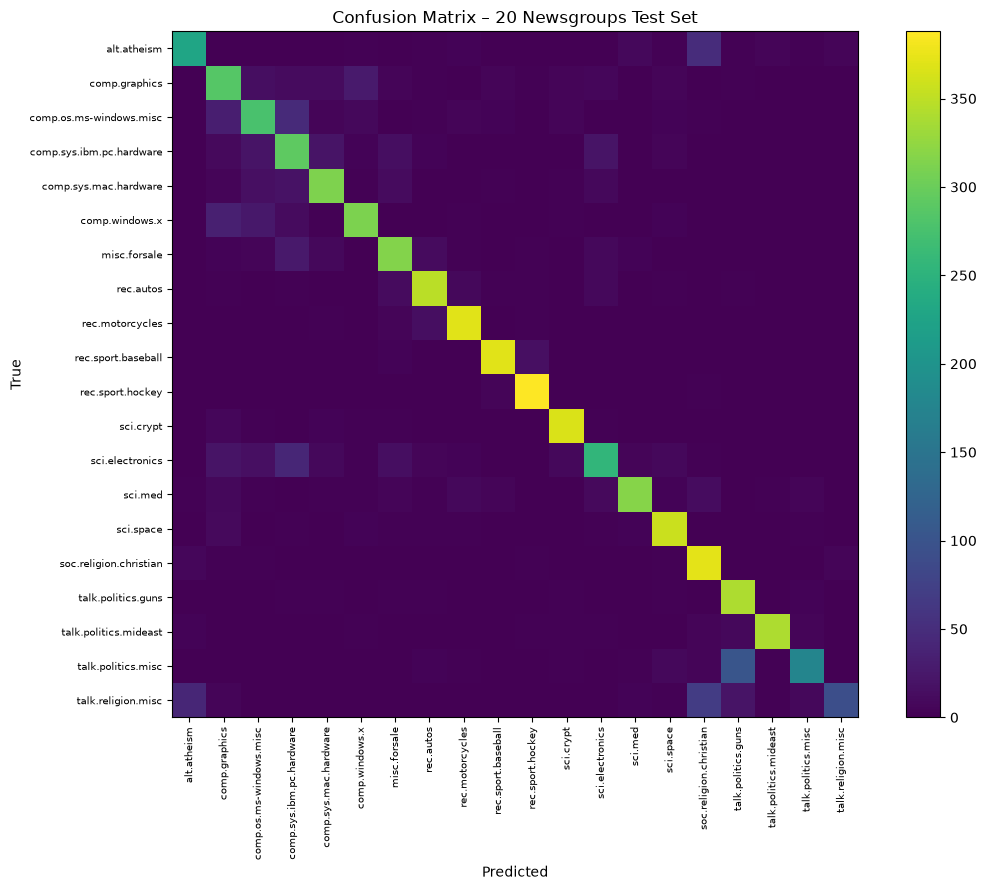

In [14]:
macro_f1 = quality_metric(y_test, y_pred)

print("Test macro-average F1:", round(macro_f1, 4))
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=LABEL_NAMES,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred, labels=LABEL_NAMES)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm)
ax.set_xticks(range(len(LABEL_NAMES)))
ax.set_yticks(range(len(LABEL_NAMES)))
ax.set_xticklabels(LABEL_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(LABEL_NAMES, fontsize=7)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix – 20 Newsgroups Test Set")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
